# Getting Skagit Data

In [1]:
import geopandas as gpd
import pandas as pd
import rioxarray
import numpy as np
import csv

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from rasterio.mask import mask

In [2]:
# create UA SWE dataset
path_ua = '../Dataset/UA_Data/'
files_ua = path_ua + '4km_SWE_Depth*.nc'
ds_ua = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars='all')

In [3]:
# clip data
skagit_boundary = gpd.read_file('../Dataset/ShapeFiles/SkagitBoundary.json')

poly = skagit_boundary.geometry.to_list()
ua_skagit_clipped = ds_ua.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.write_crs("epsg:4326", inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.clip(poly, crs="epsg:4326")

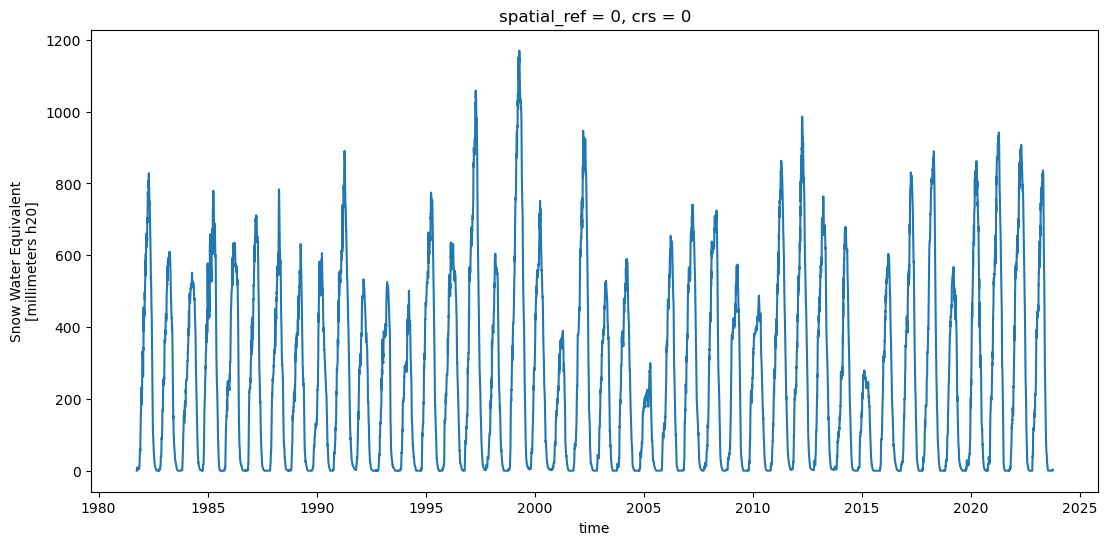

In [4]:
# plot mean
ua_skagit_clipped_mean = ua_skagit_clipped.mean(dim= ('lat', 'lon'))
ua_skagit_clipped_mean = ua_skagit_clipped_mean.assign_coords(
    year=ua_skagit_clipped_mean.time.dt.year)

plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot()

In [5]:
# read AR data
from pandas import to_datetime
import csv

AR_data = {}
AR_dates = []

with open('../Dataset/AR_Data/48N_event_data.csv') as f:
    reader = csv.reader(f)
    lines = list(reader)
    
    for line in lines:
        date = to_datetime(line[0], format='%Y%m%d%H')
        AR_dates.append(date)
        year = date.year
        scale = int(line[5])

        if year not in AR_data:
            AR_data[year] = {}
            
        AR_data[year][date] = scale
        #AR_data[year][scale] = AR_data[year].get(scale, 0) + 1

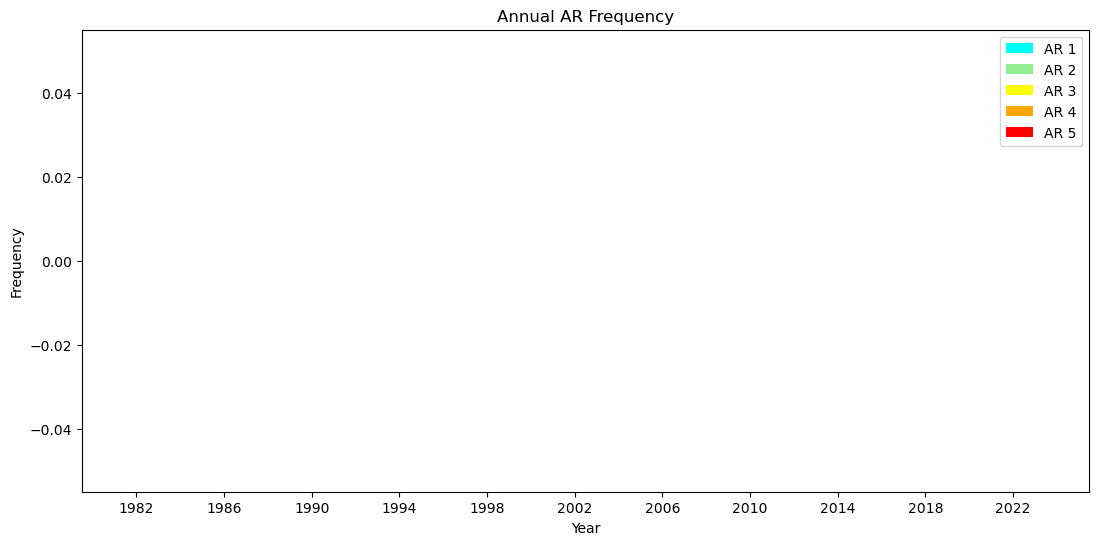

In [6]:
# plot annual frequency
years = np.array(sorted(AR_data.keys()))
# slice years to match SWE data
years = years[23:65]

ar1 = []
ar2 = []
ar3 = []
ar4 = []
ar5 = []

for year in years:
    data = AR_data[year]
    
    ar1.append(data.get(1, 0))
    ar2.append(data.get(2, 0))
    ar3.append(data.get(3, 0))
    ar4.append(data.get(4, 0))
    ar5.append(data.get(5, 0))

ar1 = np.array(ar1)
ar2 = np.array(ar2)
ar3 = np.array(ar3)
ar4 = np.array(ar4)
ar5 = np.array(ar5)

plt.figure(figsize=(13, 6))

plt.bar(years, ar1, color='cyan')
plt.bar(years, ar2, bottom=ar1, color='lightgreen')
plt.bar(years, ar3, bottom=ar1+ar2, color='yellow')
plt.bar(years, ar4, bottom=ar1+ar2+ar3, color='orange')
plt.bar(years, ar5, bottom=ar1+ar2+ar3+ar4, color='r')

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(["AR 1", "AR 2", "AR 3", "AR 4", "AR 5"])
plt.title("Annual AR Frequency")
plt.xticks(np.arange(years.min(), years.max() + 1, 4))
plt.show()

In [7]:
def filter_dates(scale, lower_bound, upper_bound):
    filtered_dates = []
    for date in AR_dates:
        year = date.year
        data = AR_data[year]

        freq = data[date]
        #freq = data.get(scale, 0)
        if freq == scale:
            filtered_dates.append(date)


    filtered_dates = [date for date in filtered_dates if lower_bound <= date.year <= upper_bound]

    return filtered_dates

In [8]:
def graph_AR_Events(dates, SWE_events, scale, color):
    plt.figure(figsize=(13, 6))
    ua_skagit_clipped_mean.plot(label='SWANN 4km')
    
    plt.scatter(dates, SWE_events, facecolors='none', edgecolors=color, s=50, label=f"AR Events (scale {scale})")
    
    plt.legend()
    plt.xlabel("Years")
    plt.title("Skagit Basin")
    plt.show()

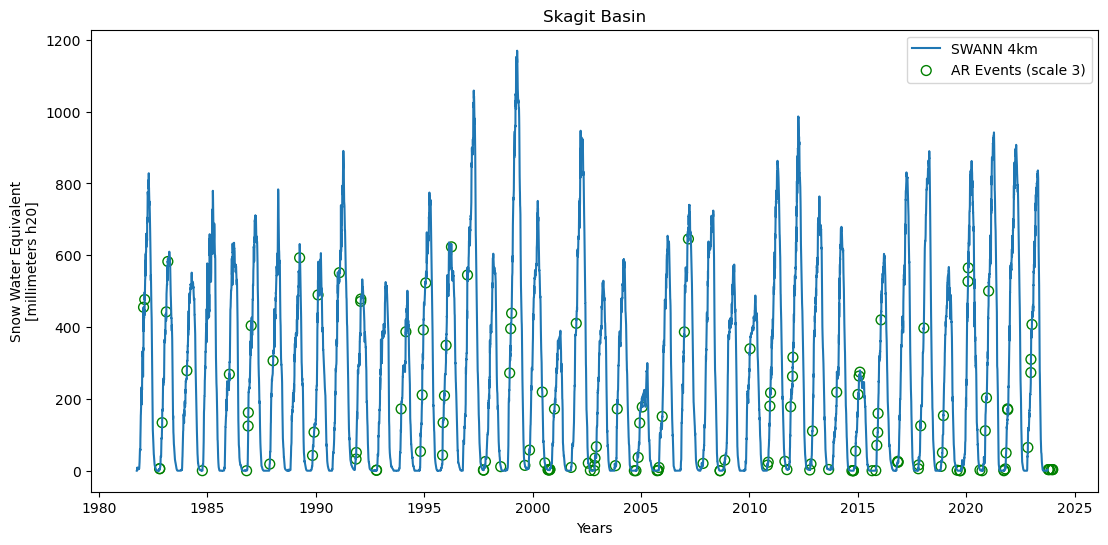

In [9]:
dates_3 = filter_dates(3, 1982, 2023)
SWE_events_3 = ua_skagit_clipped_mean.sel(time=dates_3, method='nearest')
graph_AR_Events(dates_3, SWE_events_3, 3, 'green')

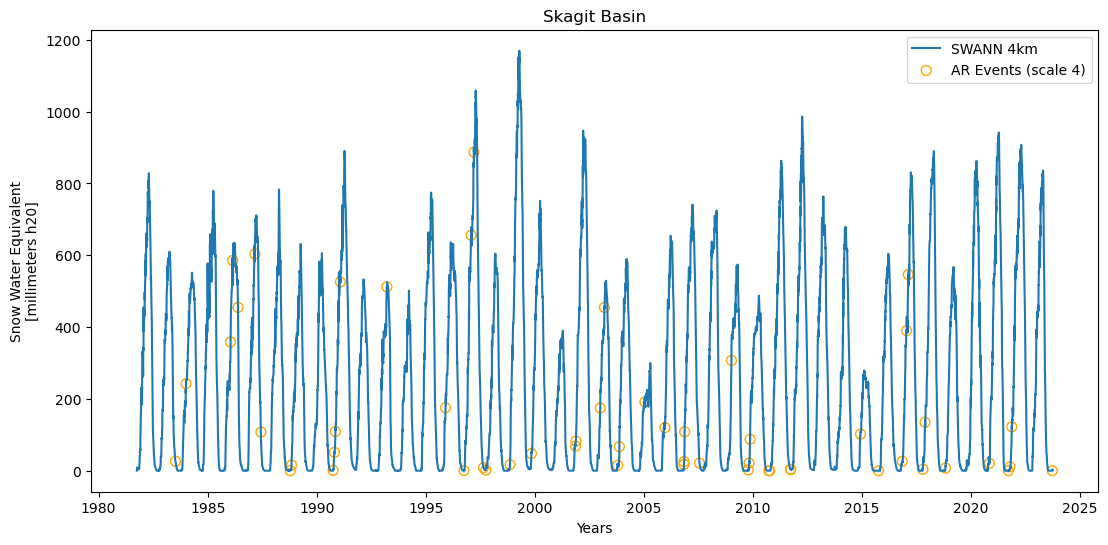

In [10]:
dates_4 = filter_dates(4, 1982, 2023)
SWE_events_4 = ua_skagit_clipped_mean.sel(time=dates_4, method='nearest')
graph_AR_Events(dates_4, SWE_events_4, 4, 'orange')

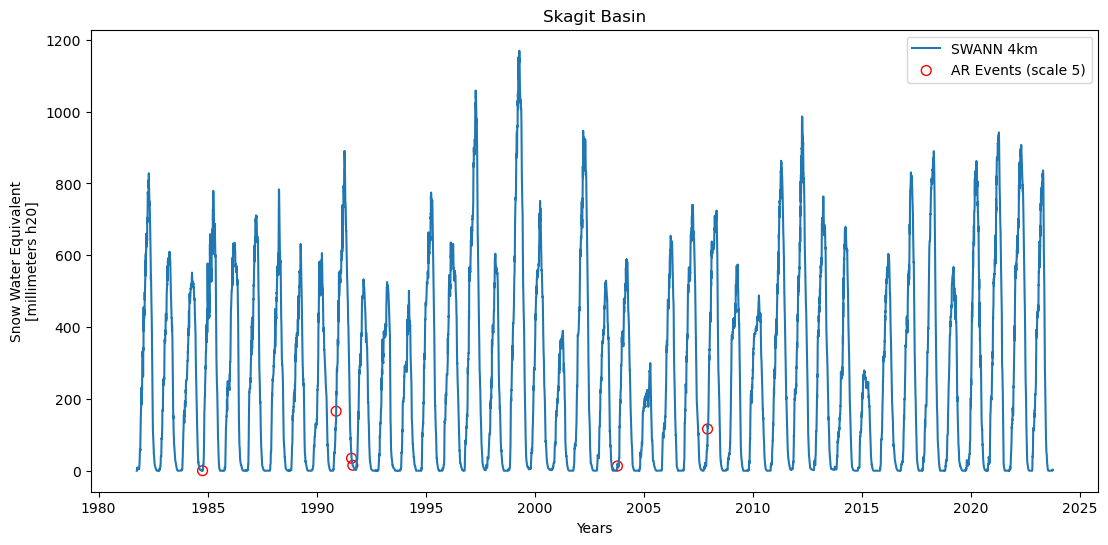

In [11]:
dates_5 = filter_dates(5, 1982, 2023)
SWE_events_5 = ua_skagit_clipped_mean.sel(time=dates_5, method='nearest')
graph_AR_Events(dates_5, SWE_events_5, 5, 'red')

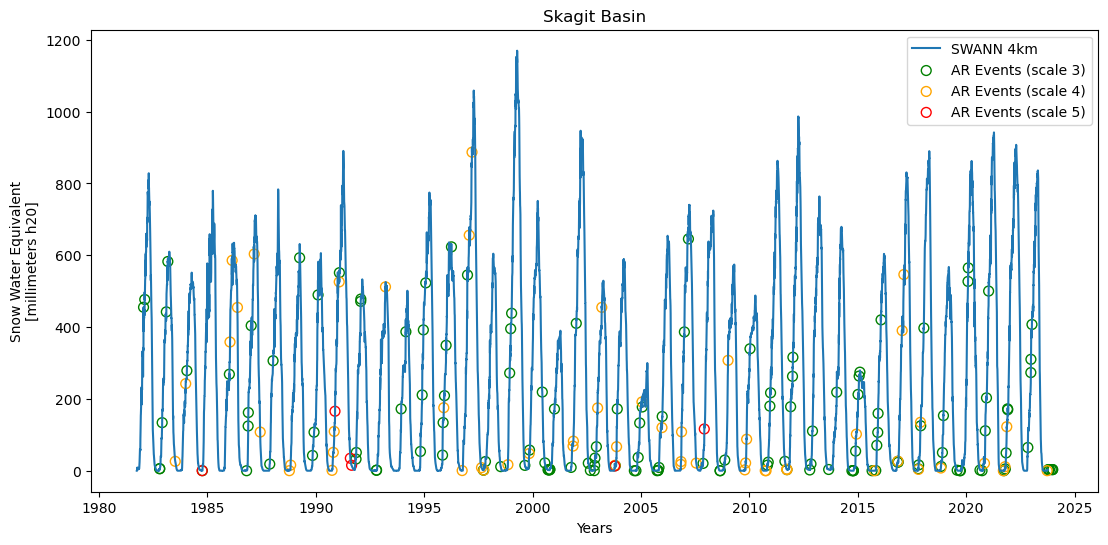

In [12]:
plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot(label='SWANN 4km')

plt.scatter(dates_3, SWE_events_3, facecolors='none', edgecolors='green', s=50, label="AR Events (scale 3)")
plt.scatter(dates_4, SWE_events_4, facecolors='none', edgecolors='orange', s=50, label="AR Events (scale 4)")
plt.scatter(dates_5, SWE_events_5, facecolors='none', edgecolors='red', s=50, label="AR Events (scale 5)")

plt.legend()
plt.xlabel("Years")
plt.title("Skagit Basin")
plt.show()

### StreamFlow Data

In [13]:
import dataretrieval

In [14]:
site_name = 'Skagit River'
csv_filename = 'skagit-river-streamflow(24-25).csv'

# ~ 3 years of data
start_date = '2022-12-18'
end_date = '2025-12-18'
site_num = '12200500'

In [15]:
# Get discharge data and metadata from NWIS if not already downloaded
from pathlib import Path

project = Path('../Dataset/Streamflow/')
nwis_path = project / csv_filename

while not nwis_path.exists():
    try:
        nwis_df, meta = dataretrieval.nwis.get_dv(
            sites=site_number,
            start=start_date,
            end=end_date)
            
        nwis_df.to_csv(nwis_path)
    except:
        continue

def change_year(y): # y is int
    if y > 26:
        y += 1900
    else:
        y += 2000
        
    return y

In [16]:
# # Load from file
nwis_df = pd.read_csv(nwis_path)

dates = []
for date in nwis_df['time']:
    year = int(date[-2:])
    year = change_year(year) # now its 4 digits

    date = to_datetime(date, format='%m/%d/%y')
    date = date.replace(year=year)

    dates.append(date)
    

nwis_df['time'] = pd.to_datetime(dates, format='%m/%d/%Y')
nwis_df.set_index('time', inplace=True)

In [17]:
def get_discharge_values(dates):
    values = []
    for date in dates:
        date = date.normalize() # no hours
        idx = nwis_df.index.get_indexer([date], method='nearest')[0]
        value = nwis_df.iloc[idx]['value']
        
        values.append(value)

    return values

In [18]:
dates_3 = filter_dates(3, 2024, 2025)
SF_events_3 = get_discharge_values(dates_3)

dates_4 = filter_dates(4, 2024, 2025)
SF_events_4 = get_discharge_values(dates_4)

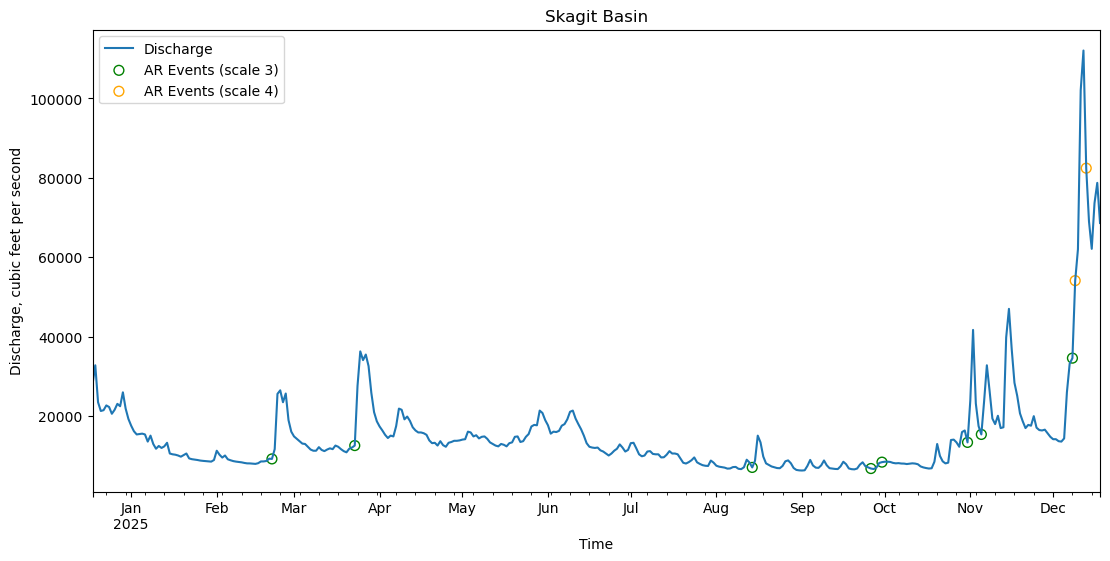

In [19]:
plt.figure(figsize=(13, 6))
nwis_df['value'].plot(label='Discharge')

plt.scatter(dates_3, SF_events_3, facecolors='none', edgecolors='green', s=50, label="AR Events (scale 3)")
plt.scatter(dates_4, SF_events_4, facecolors='none', edgecolors='orange', s=50, label="AR Events (scale 4)")

plt.legend()
plt.xlabel("Time")
plt.ylabel("Discharge, cubic feet per second")
plt.title("Skagit Basin")
plt.show()